In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [3]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

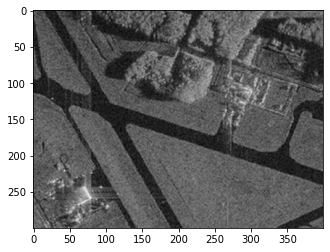

In [4]:
plt.imshow(image_gray, cmap="gray")

# Алгоритм разрастания регионов

In [52]:
import math
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])
                                                            
    if abs(av_val - img[point]) <= T:
        return True
    
    return False
    

In [53]:
def region_growing(image, seed_point,homo_fun,r, T):
    mask = np.zeros(image_gray.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image_gray.shape, np.uint8)
        for i in range(r,image.shape[0] - r):
            for j in range(r,image.shape[1] - r):
                if mask[i,j]==0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        print(count)
        mask += local_mask
        
    return mask*255
    

In [67]:
seed_point = (250,250)
mask = region_growing(image_gray,seed_point,homo_average,1, 10)

3
,4
,4
,5
,7
,6
,6
,9
,7
,6
,6
,9
,13
,12
,15
,17
,13
,13
,16
,16
,14
,16
,15
,16
,10
,11
,14
,13
,14
,10
,10
,14
,17
,15
,36
,22
,21
,18
,21
,21
,25
,23
,43
,31
,34
,23
,20
,27
,29
,35
,40
,32
,35
,42
,48
,52
,30
,23
,20
,19
,19
,20
,18
,22
,74
,24
,26
,29
,30
,27
,29
,29
,28
,29
,20
,17
,17
,21
,20
,25
,23
,24
,20
,18
,19
,15
,18
,18
,15
,18
,13
,10
,9
,7
,9
,9
,10
,11
,12
,10
,12
,11
,8
,9
,7
,4
,3
,6
,6
,6
,5
,5
,5
,3
,2
,2
,2
,1
,0


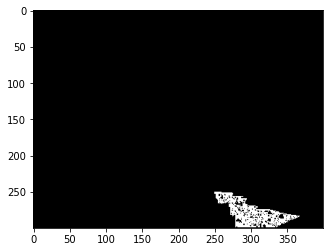

In [68]:
plt.imshow(mask, cmap="gray")

# K-means

In [7]:
# Define criteria = ( type, max_iter = 10 , epsilon = 1.0 )
# criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

In [8]:
flags = cv2.KMEANS_RANDOM_CENTERS

In [10]:
z = image_gray.reshape((-1,3))
# convert to np.float32
z = np.float32(z)
# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
ret,label,center=cv2.kmeans(z,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
# Now convert back into uint8, and make original image
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((image_gray.shape))

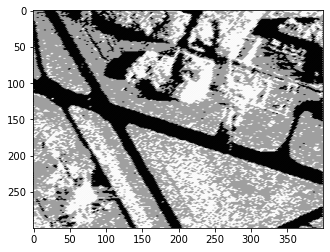

In [11]:
plt.imshow(res2, cmap="gray")

# Watershed+Distance transform

In [5]:
image = cv2.imread('oranges_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

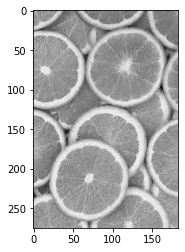

In [6]:
plt.imshow(image_gray, cmap="gray")

In [7]:
ret, thresh = cv2.threshold(image_gray,0,255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

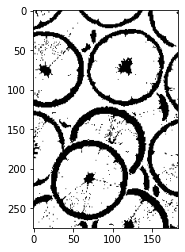

In [8]:
plt.imshow(thresh, cmap="gray")

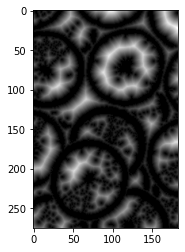

In [9]:
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5) 
plt.imshow(dist, cmap="gray")

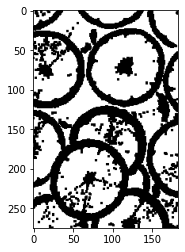

In [11]:
ret, sure_fg = cv2.threshold(dist, 0.1 * dist.max(), 255, cv2.THRESH_BINARY) 
plt.imshow(sure_fg, cmap="gray")

In [20]:
sure_fg = sure_fg.astype(np.uint8)

In [21]:
ret, markers = cv2.connectedComponents(sure_fg) 

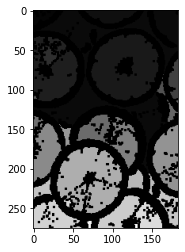

In [22]:
plt.imshow(markers, cmap="gray")

In [30]:
markers = cv2.watershed(image, markers)

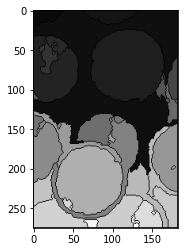

In [34]:
plt.imshow(markers, cmap="gray")

In [35]:
# ДЗ
# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

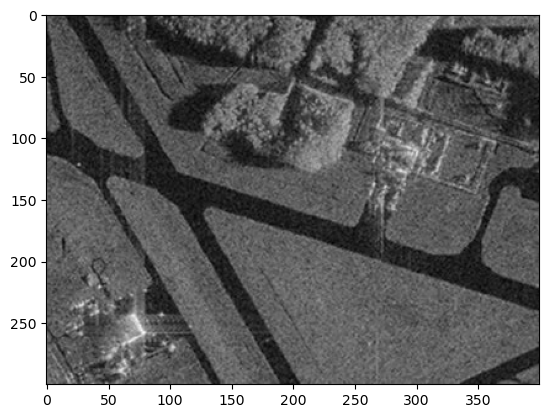

In [3]:
plt.imshow(image_gray, cmap="gray")

In [4]:
import math
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])
                                                            
    if abs(av_val - img[point]) <= T:
        return True
    
    return False

In [5]:
def region_growing(image, seed_point,homo_fun,r, T):
    mask = np.zeros(image_gray.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image_gray.shape, np.uint8)
        for i in range(r,image.shape[0] - r):
            for j in range(r,image.shape[1] - r):
                if mask[i,j]==0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        print(count)
        mask += local_mask
        
    return mask*255

In [14]:
seed_point = (250, 250)
mask = region_growing(image_gray, seed_point, homo_average, 7, 20)

184
525
845
1190
1515
1842
1517
1581
1467
1339
1228
1137
1103
1273
1338
1495
1474
1614
1903
1769
1509
1580
1521
1617
1720
2378
2181
1960
1465
1577
1482
1521
1784
1678
1619
1753
2392
1813
1649
1813
1523
465
384
393
456
497
490
469
402
534
632
650
434
343
341
379
397
366
234
108
68
11
0


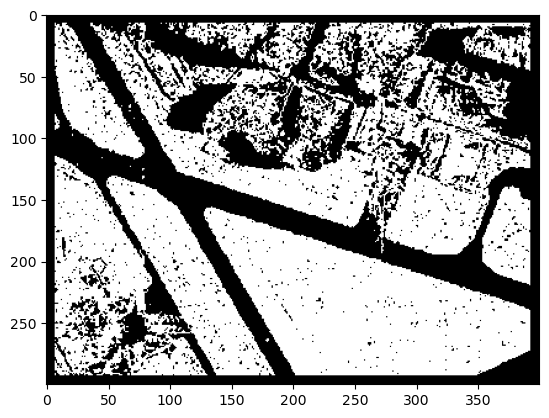

In [15]:
plt.imshow(mask, cmap="gray")

In [6]:
def homo_local(img, mask, point, T):
    i, j = point
    region_mean = img[mask > 0].mean()
    local_mean = img[max(i-2, 0):i+3, max(j-2, 0):j+3].mean()
    if abs(region_mean - local_mean) <= T:
        return True
    return False

In [7]:
seed_point = (250, 250)
mask2 = region_growing(image_gray, seed_point, homo_local, 10, 30)

399
1121
1843
2488
2283
2244
1994
1756
1485
1472
1675
1575
1357
1090
991
1011
1030
1063
1115
1278
1172
1381
1399
1549
1824
2239
2365
1978
2678
3091
3534
3738
3496
4194
4469
3942
2604
1893
1588
1306
1234
1167
998
517
22
0


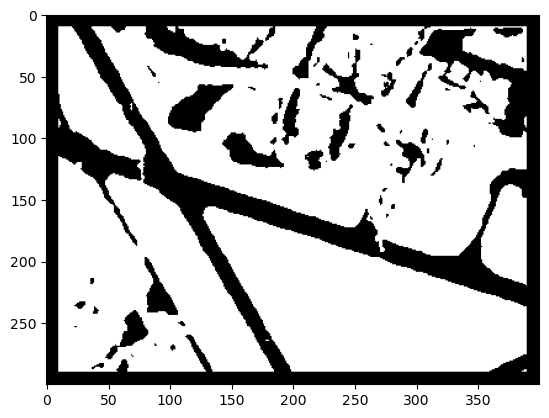

In [8]:
plt.imshow(mask2, cmap="gray")

Реализован критерий homo_local: среднее в окне 5×5 вокруг пикселя сравнивается со средним области. Он устойчивее к шуму SAR-снимка, чем homo_average.
При одинаковых параметрах homo_local оставался в одном поле и не переходил через дорогу: homo_average перепрыгивает её за счёт отдельных шумовых пикселей, а в усреднённых значениях такие выбросы сглажены. Поэтому параметры подбирались отдельно: homo_average - r=7, T=20; homo_local - r=10, T=30.
Оба критерия выделяют газон и не захватывают дороги, но частично заходят в области с деревьями. homo_average даёт «рваную» маску с множеством дыр от шума, homo_local даёт сплошную маску с чёткими границами.

In [30]:
image = cv2.imread('palm_1.JPG')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

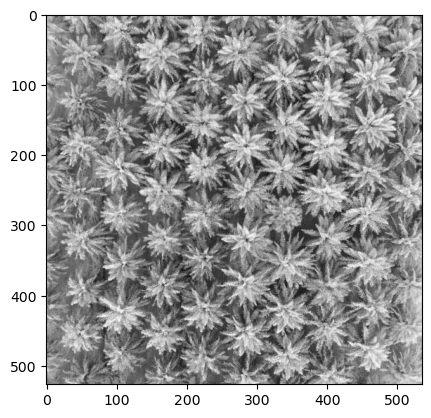

In [31]:
plt.imshow(image_gray, cmap="gray")

In [32]:
blur = cv2.GaussianBlur(image_gray, (9,9), 0)
ret, thresh = cv2.threshold(blur,0,255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

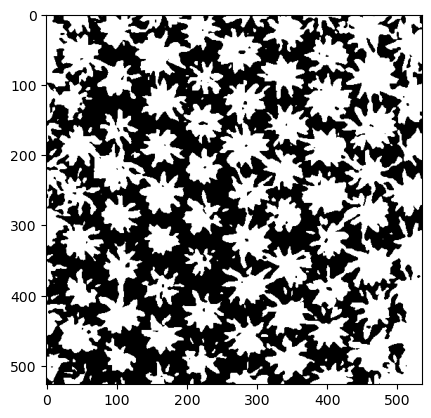

In [33]:
plt.imshow(thresh, cmap="gray")

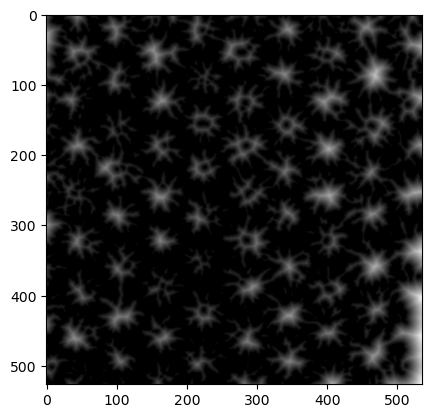

In [34]:
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5) 
plt.imshow(dist, cmap="gray")

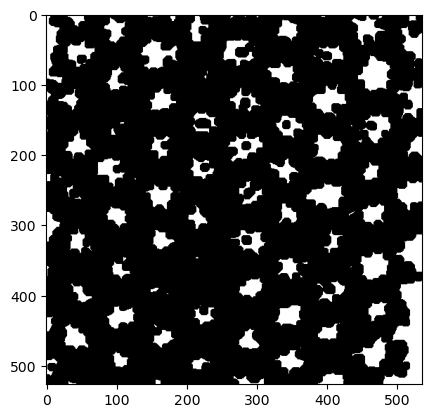

In [35]:
ret, sure_fg = cv2.threshold(dist, 0.2 * dist.max(), 255, cv2.THRESH_BINARY) 
plt.imshow(sure_fg, cmap="gray")

In [36]:
sure_fg = sure_fg.astype(np.uint8)

In [44]:
ret, markers = cv2.connectedComponents(sure_fg) 

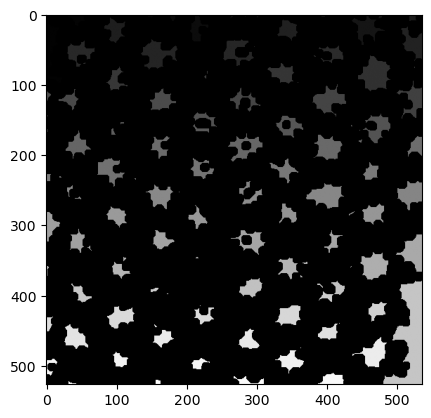

In [46]:
plt.imshow(markers, cmap="gray")

In [47]:
markers = cv2.watershed(image, markers)

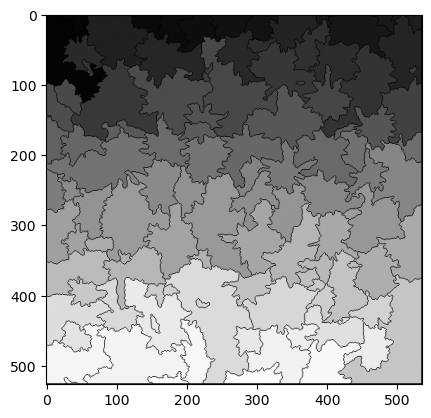

In [48]:
plt.imshow(markers, cmap="gray")

In [53]:
print("Количество пальм:", len(np.unique(markers)) - 1)

Количество пальм: 118
